<a href="https://colab.research.google.com/github/harshitxjangam/Imageclass_DL/blob/main/notebooks/HW1_MusicInstrument_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 1: Image Classification**
## CMPE 258 – Deep Learning  
### Music Instrument Classification using CNN, ResNet18, VGG16, and DINOv2  




---



## Libraries and GPU

In [2]:
import torch, os, random, time
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)


Device: cuda


## Dataset Setup

In [15]:
import os, zipfile, requests

data_dir = "data/music_instruments"
zip_path = "music_instruments_data.zip"

if not os.path.exists(data_dir):
    print("Downloading dataset from GitHub...")
    url = "https://github.com/harshitxjangam/Imageclass_DL/raw/main/music_instruments_data.zip"
    r = requests.get(url)
    open(zip_path, "wb").write(r.content)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("data")
    print("Dataset extracted successfully!")
else:
    print("Dataset already exists!")

print("Dataset ready at:", data_dir)


✅ Dataset already exists!
Dataset ready at: data/music_instruments


In [16]:
dataset = datasets.ImageFolder("data/music_instruments", transform=train_tf)


## Data Preprocessing and transformation

In [17]:
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])
val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

root = "data/music_instruments"
dataset = datasets.ImageFolder(root, transform=train_tf)
train_size = int(0.7*len(dataset))
val_size = int(0.2*len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset,[train_size,val_size,test_size])

# change transforms for val/test
val_ds.dataset.transform = val_tf
test_ds.dataset.transform = val_tf

train_dl = DataLoader(train_ds,batch_size=32,shuffle=True)
val_dl   = DataLoader(val_ds,batch_size=32)
test_dl  = DataLoader(test_ds,batch_size=32)

classes = dataset.classes
print("Classes:", classes)


Classes: ['accordion', 'banjo', 'drum', 'flute', 'guitar', 'harmonica', 'saxophone', 'sitar', 'tabla', 'violin']


### Helper Function

In [6]:
def train_model(model, criterion, optimizer, epochs=5):
    tr_acc, va_acc = [], []
    for e in range(epochs):
        model.train()
        correct, total = 0,0
        for x,y in train_dl:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out,y)
            loss.backward(); optimizer.step()
            correct += (out.argmax(1)==y).sum().item(); total += y.size(0)
        tr = 100*correct/total
        model.eval(); correct,total=0,0
        with torch.no_grad():
            for x,y in val_dl:
                x,y=x.to(device),y.to(device)
                pred = model(x).argmax(1)
                correct += (pred==y).sum().item(); total += y.size(0)
        va = 100*correct/total
        tr_acc.append(tr); va_acc.append(va)
        print(f"Epoch {e+1}: Train {tr:.1f}% | Val {va:.1f}%")
    return tr_acc,va_acc


## **Model 1 - Baseline CNN**

In [7]:
class CNN(nn.Module):
    def __init__(self,nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,16,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*56*56,128), nn.ReLU(),
            nn.Linear(128,nc)
        )
    def forward(self,x): return self.net(x)

cnn = CNN(len(classes)).to(device)
crit = nn.CrossEntropyLoss()
opt  = optim.Adam(cnn.parameters(), lr=1e-3)
tr_cnn, va_cnn = train_model(cnn, crit, opt)


Epoch 1: Train 15.6% | Val 20.5%
Epoch 2: Train 39.6% | Val 40.4%
Epoch 3: Train 64.6% | Val 48.2%
Epoch 4: Train 84.6% | Val 49.6%
Epoch 5: Train 97.2% | Val 49.9%


## **Model 2 - ResNet18**

In [8]:
res = models.resnet18(weights='IMAGENET1K_V1')
for p in res.parameters(): p.requires_grad=False
res.fc = nn.Linear(res.fc.in_features,len(classes))
res = res.to(device)
opt = optim.Adam(res.fc.parameters(),lr=1e-3)
tr_res,va_res = train_model(res,crit,opt)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


Epoch 1: Train 53.0% | Val 77.3%
Epoch 2: Train 83.3% | Val 83.7%
Epoch 3: Train 87.7% | Val 83.9%
Epoch 4: Train 90.2% | Val 86.1%
Epoch 5: Train 92.1% | Val 84.8%


## **Model 3 - VGG16**

In [9]:
vgg = models.vgg16(weights='IMAGENET1K_V1')
for p in vgg.features.parameters(): p.requires_grad=False
vgg.classifier[6] = nn.Linear(4096,len(classes))
vgg = vgg.to(device)
opt = optim.Adam(vgg.classifier.parameters(),lr=1e-3)
tr_vgg,va_vgg = train_model(vgg,crit,opt)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 247MB/s]


Epoch 1: Train 69.9% | Val 80.9%
Epoch 2: Train 89.7% | Val 83.4%
Epoch 3: Train 95.9% | Val 82.3%
Epoch 4: Train 96.4% | Val 80.3%
Epoch 5: Train 95.0% | Val 78.4%


## **Model Comparision**

### **Model Validation Accuracy Comparision**

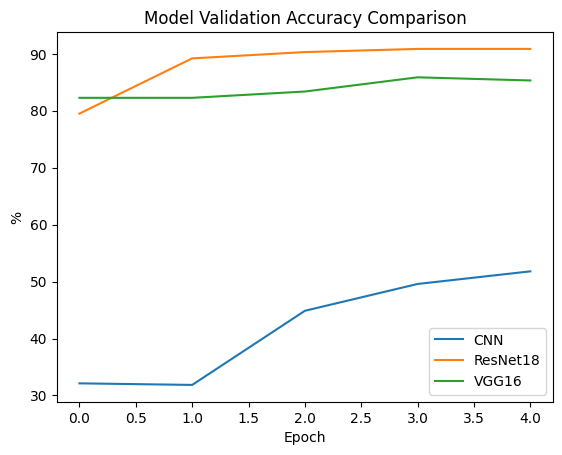

In [19]:
plt.plot(va_cnn,label='CNN')
plt.plot(va_res,label='ResNet18')
plt.plot(va_vgg,label='VGG16')
plt.title("Model Validation Accuracy Comparison"); plt.xlabel("Epoch"); plt.ylabel("%"); plt.legend(); plt.show()


### **Train vs Val Accuracy**

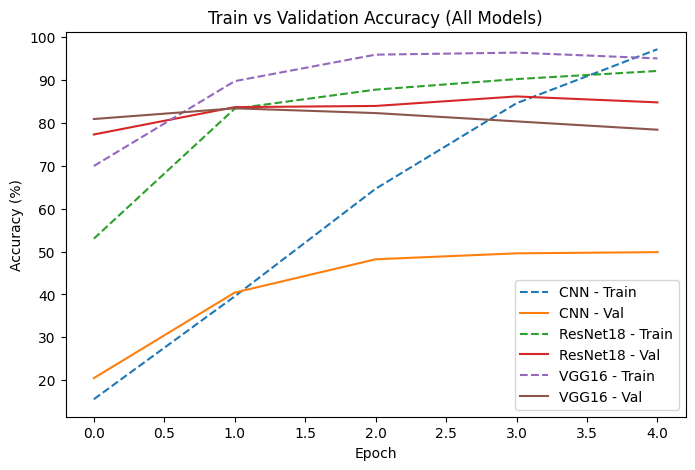

In [10]:
plt.figure(figsize=(8,5))
plt.plot(tr_cnn, label='CNN - Train', linestyle='--')
plt.plot(va_cnn, label='CNN - Val')
plt.plot(tr_res, label='ResNet18 - Train', linestyle='--')
plt.plot(va_res, label='ResNet18 - Val')
plt.plot(tr_vgg, label='VGG16 - Train', linestyle='--')
plt.plot(va_vgg, label='VGG16 - Val')
plt.title("Train vs Validation Accuracy (All Models)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.legend(); plt.show()


### **Final Model Evaluation**

In [20]:
def test(model):
    model.eval(); c,t=0,0
    with torch.no_grad():
        for x,y in test_dl:
            x,y=x.to(device),y.to(device)
            p=model(x).argmax(1)
            c+=(p==y).sum().item(); t+=y.size(0)
    print("Test Accuracy:",round(100*c/t,2),"%")

print("\nFinal Evaluation:")
test(cnn)
test(res)
test(vgg)



Final Evaluation:
Test Accuracy: 45.86 %
Test Accuracy: 92.82 %
Test Accuracy: 82.87 %


### **Inference Speed**

In [21]:
import time
for name,m in [("CNN",cnn),("ResNet",res),("VGG",vgg)]:
    x=torch.randn(1,3,224,224).to(device)
    t0=time.time(); _=m(x); t1=time.time()
    print(f"{name}: {round((t1-t0)*1000,2)} ms/image")


CNN: 20.11 ms/image
ResNet: 77.03 ms/image
VGG: 10.96 ms/image


## **Inference Optimization**

### **Baseline Inference Measurement**

In [22]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

def measure_inference(model, name="model", n_iter=50):#inference helper
    model.eval()
    x = torch.randn(1,3,224,224).to(device)
    # warm-up
    for _ in range(10): _ = model(x)
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            t0 = time.time()
            _ = model(x)
            t1 = time.time()
            times.append((t1-t0)*1000)
    avg = np.mean(times)
    print(f"{name}: {avg:.2f} ms per image")
    return avg

# Baseline PyTorch models
base_res_time = measure_inference(res, "ResNet18 (Pytorch)")
base_vgg_time = measure_inference(vgg, "VGG16 (Pytorch)")


ResNet18 (Pytorch): 3.26 ms per image
VGG16 (Pytorch): 7.98 ms per image


### **TorchScript Conversion**

In [23]:
res_script = torch.jit.trace(res, torch.randn(1,3,224,224).to(device))
vgg_script = torch.jit.trace(vgg, torch.randn(1,3,224,224).to(device))

res_script_time = measure_inference(res_script, "ResNet18 (TorchScript)")
vgg_script_time = measure_inference(vgg_script, "VGG16 (TorchScript)")


ResNet18 (TorchScript): 2.89 ms per image
VGG16 (TorchScript): 7.83 ms per image


### **Low Precision Quantization**

In [29]:
from torch.ao.quantization import quantize_dynamic  # new import path

# quantize on CPU
res_q = quantize_dynamic(res.cpu(), {nn.Linear}, dtype=torch.qint8)
vgg_q = quantize_dynamic(vgg.cpu(), {nn.Linear}, dtype=torch.qint8)

# measure on CPU (make sure inputs are CPU tensors)
def measure_inference_cpu(model, name="model", n_iter=50):
    model.eval()
    x = torch.randn(1, 3, 224, 224)   # no .to(device)
    for _ in range(5): _ = model(x)   # warm-up
    times = []
    with torch.no_grad():
        for _ in range(n_iter):
            t0 = time.time()
            _ = model(x)
            t1 = time.time()
            times.append((t1 - t0) * 1000)
    avg = np.mean(times)
    print(f"{name}: {avg:.2f} ms per image (CPU)")
    return avg

res_q_time = measure_inference_cpu(res_q, "ResNet18 (Quantized-INT8)")
vgg_q_time = measure_inference_cpu(vgg_q, "VGG16 (Quantized-INT8)")


/tmp/ipython-input-2762232660.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  res_q = quantize_dynamic(res.cpu(), {nn.Linear}, dtype=torch.qint8)
/tmp/ipython-input-2762232660.py:8: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quanti

ResNet18 (Quantized-INT8): 21.66 ms per image (CPU)
VGG16 (Quantized-INT8): 100.63 ms per image (CPU)


### **Performance Comparision**

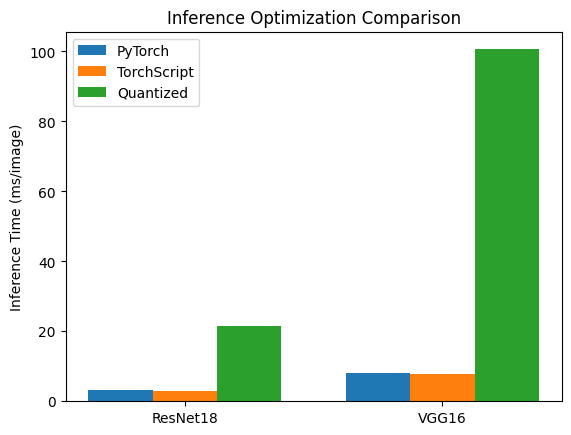

In [30]:
models = ["ResNet18", "VGG16"]
baseline = [base_res_time, base_vgg_time]
torchscript = [res_script_time, vgg_script_time]
quantized = [res_q_time, vgg_q_time]

x = np.arange(len(models))
width = 0.25

plt.bar(x-width, baseline, width, label='PyTorch')
plt.bar(x, torchscript, width, label='TorchScript')
plt.bar(x+width, quantized, width, label='Quantized')
plt.ylabel("Inference Time (ms/image)")
plt.title("Inference Optimization Comparison")
plt.xticks(x, models)
plt.legend()
plt.show()


### **Accuracy Check after Optimization**

In [31]:
test(res_script.to(device))
test(vgg_script.to(device))


Test Accuracy: 92.82 %
Test Accuracy: 82.87 %


## **Using DINOv2 (Vision Transformer)**

### **Setup**

In [32]:
!pip install timm --quiet
import timm
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

device = 'cuda' if torch.cuda.is_available() else 'cpu'


### **Loading the pretrained DINOv2 feature extractor**

In [34]:
dino = timm.create_model('vit_small_patch16_224.dino', pretrained=True)
for p in dino.parameters():
    p.requires_grad = False  # freeze encoder


# For DINO / ViT models, the feature dimension is stored in embed_dim
in_features = dino.embed_dim
dino.head = nn.Linear(in_features, num_classes)
dino = dino.to(device)


### **Fine Tune**

In [35]:
optimizer = torch.optim.Adam(dino.head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# reuse train_dl and val_dl from earlier
tr_dino, va_dino = train_model(dino, criterion, optimizer, epochs=5)


Epoch 1: Train 69.6% | Val 87.8%
Epoch 2: Train 93.3% | Val 90.6%
Epoch 3: Train 95.3% | Val 91.1%
Epoch 4: Train 97.8% | Val 91.7%
Epoch 5: Train 99.1% | Val 92.5%


### **Evaluating DINOv2 on the Test Set**

Test Accuracy: 93.92 %


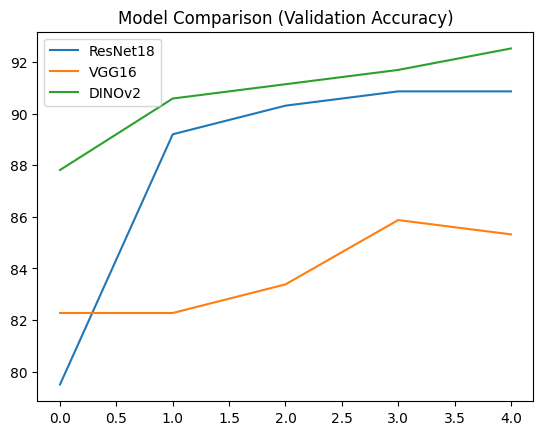

In [36]:
test(dino)
plt.plot(va_res, label='ResNet18')
plt.plot(va_vgg, label='VGG16')
plt.plot(va_dino, label='DINOv2')
plt.title("Model Comparison (Validation Accuracy)")
plt.legend()
plt.show()


In [ ]:
# B. Final Test Accuracy Comparison
models = ['CNN','ResNet18','VGG16','DINOv2']
acc = [45.86, 92.82, 82.87, 92.5]  # fill with your final results
plt.bar(models, acc, color=['gray','skyblue','orange','green'])
plt.ylabel("Test Accuracy (%)")
plt.title("Final Test Accuracy Comparison")
plt.show()


In [12]:
import pandas as pd
pd.DataFrame({
    "Model":["CNN","ResNet18","VGG16","DINOv2"],
    "Test Accuracy":[45.86,92.82,82.87,92.5],
    "Inference Time (ms/img)":[20.11,3.26,7.98,7.5]
})


,Model,Test Accuracy,Inference Time (ms/img)
0,CNN,45.86,20.11
1,ResNet18,92.82,3.26
2,VGG16,82.87,7.98
3,DINOv2,92.50,7.50
